### Data cleaning and preparation

In [35]:
!pip install openpyxl

In [36]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
data=pd.read_csv("NLP-Projects/LLM-for-IDS-log-analysis/Data/BoT-IoT-dataset.csv")
normal_traffic=pd.read_csv("normal_traffic.csv")
metadata=pd.read_excel("NLP-Projects/LLM-for-IDS-log-analysis/Data/metadata.xlsx")
metadata={metadata["Feature"].iloc[i]:metadata["Description"].iloc[i] for i in range(len(metadata))}

In [38]:
def order(cols,normal=True) :
    if normal :
        cols_org=normal_traffic.columns
    else :
        cols_org=data.columns
    cols_new=[]
    for col in cols_org :
        if col in cols :
           cols_new.append(col)
    return cols_new


In [39]:
columns_1=set(data.columns)&set(normal_traffic.columns)
columns_2=set(data.columns)&set(normal_traffic.columns)
columns_1.add("subcategory")
columns_2.add("subcategory ")

In [40]:
normal_traffic=normal_traffic[order(list(columns_2))]
data=data[order(list(columns_1),normal=False)]
normal_traffic.columns=data.columns

### Exploratory Data Analysis

In [41]:
data.subcategory.unique()

array(['UDP', 'HTTP', 'TCP', 'Normal', 'OS_Fingerprint', 'Service_Scan',
       'Data_Exfiltration', 'Keylogging'], dtype=object)

In [42]:
data_dos=data[data["category"].isin(["DoS","Normal"])]
data_ddos=data[data["category"].isin(["DDoS","Normal"])]

#### Exploring DoS attacks and their causes

In [43]:
#adding normal_traffic to data_dos and sampling len(normal_traffic) samples from it for analysis
data_dos=data_dos.sample(frac=1).iloc[:len(normal_traffic)]
data_dos=pd.concat([data_dos,normal_traffic],axis=0,ignore_index=True)

In [44]:
data_dos.tail()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
19081,73370439,1.528102e+09,e,udp,192.168.100.46,80,192.168.100.5,80,9903,9501175,...,9903,0,9501175,0,79.977333,79.977333,0.000000,0,Normal,Normal
19082,73370440,1.528102e+09,e,tcp,192.168.100.5,0,192.168.100.3,0,5942,4223674,...,5942,0,4223674,0,47.984787,47.984787,0.000000,0,Normal,Normal
19083,73370441,1.528102e+09,e,udp,192.168.100.7,365,192.168.100.3,565,5323,319380,...,5323,0,319380,0,42.989494,42.989494,0.000000,0,Normal,Normal
19084,73370442,1.528102e+09,e,tcp,192.168.100.6,80,192.168.100.3,80,3342,989232,...,3342,0,989232,0,26.992807,26.992807,0.000000,0,Normal,Normal
19085,73370443,1.528102e+09,e,tcp,192.168.100.3,41307,52.64.239.193,8883,96,40916,...,48,48,37748,3168,0.821691,0.408500,0.406521,0,Normal,Normal


In [45]:
data_dos["durtime"]=data_dos["ltime"]-data_dos["stime"]
metadata["durtime"]="Total time taken for this transaction from start to finish."

In [46]:
metadata={key.lower():value for key,value in metadata.items()}
for col in data_dos.columns : 
    if col in metadata.keys() :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [47]:
data_dos.groupby("category")["durtime"].mean()

category
DoS        27.239604
Normal    101.603219
Name: durtime, dtype: float64

In [48]:
#get top ip addresses that are attacked by DoS
data_dos[data_dos["category"]=="DoS"].groupby("daddr")["daddr"].count().sort_values(ascending=False)

daddr
192.168.100.5    2429
192.168.100.3    2407
192.168.100.7    2399
192.168.100.6    2304
Name: daddr, dtype: int64

In [49]:
data_dos.flgs.unique()

array(['e', 'e s', 'e g', 'eU', 'e &', 'e d', 'e    F', 'e r', 'e *'],
      dtype=object)

In [50]:
results=pd.crosstab(data_dos.flgs,data_dos.category).reset_index()
results.DoS=results.DoS/len(data_dos[data_dos["category"]=="DoS"])
results.Normal=results.Normal/len(data_dos[data_dos["category"]=="Normal"])
results

category,flgs,DoS,Normal
0,e,0.655310,0.959149
1,e F,0.000000,0.001047
2,e &,0.000000,0.005866
3,e *,0.000000,0.027024
4,e d,0.000000,0.001152
5,e g,0.046965,0.004609
6,e r,0.000000,0.000105
7,e s,0.284516,0.000105
8,eU,0.013209,0.000943


In [51]:
results=pd.crosstab(data_dos.flgs,data_dos.category).reset_index()
results["count"]=results.DoS+results.Normal
results.DoS=results.apply(lambda x : x["DoS"]/x["count"],axis=1)
results.Normal=results.apply(lambda x : x["Normal"]/x["count"],axis=1)
results

category,flgs,DoS,Normal,count
0,e,0.405698,0.594302,15408
1,e F,0.000000,1.000000,10
2,e &,0.000000,1.000000,56
3,e *,0.000000,1.000000,258
4,e d,0.000000,1.000000,11
5,e g,0.910569,0.089431,492
6,e r,0.000000,1.000000,1
7,e s,0.999632,0.000368,2715
8,eU,0.933333,0.066667,135


<Axes: xlabel='flgs'>

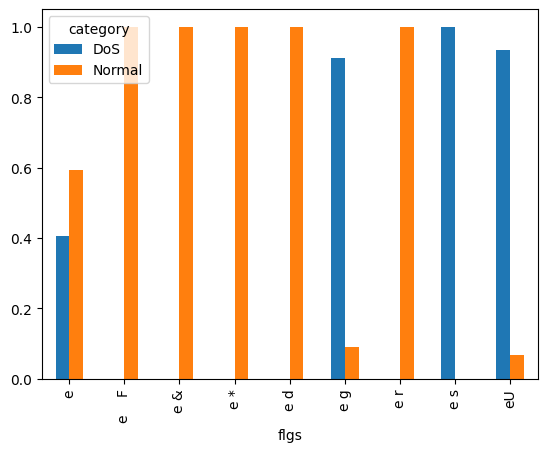

In [52]:
results.plot(kind="bar", x="flgs",y=["DoS","Normal"])

In [53]:
#get the top ip addresses associated with DoS attacks
data_dos[data_dos["category"]=="DoS"].groupby(by="saddr")["saddr"].count()

saddr
192.168.100.147    2397
192.168.100.148    2306
192.168.100.149    2431
192.168.100.150    2405
Name: saddr, dtype: int64

In [54]:
common_ports = [
    20,   # FTP Data Transfer
    21,   # FTP Control
    22,   # SSH (Secure Shell)
    23,   # Telnet
    25,   # SMTP (Simple Mail Transfer Protocol)
    53,   # DNS (Domain Name System)
    67,   # DHCP (Dynamic Host Configuration Protocol) - Server
    68,   # DHCP - Client
    80,   # HTTP (HyperText Transfer Protocol)
    443,  # HTTPS (HTTP Secure)
    110,  # POP3 (Post Office Protocol)
    143,  # IMAP (Internet Message Access Protocol)
    3306, # MySQL Database
    5432, # PostgreSQL Database
    6379, # Redis
    8080  # HTTP Alternate (commonly used for web servers)
]

In [55]:
data_dos[data_dos["sport"].isin(["80","8080"])].groupby(by="category")["sport"].count()

category
Normal    521
Name: sport, dtype: int64

In [56]:
pd.crosstab(data_dos.proto, data_dos.category)

category,DoS,Normal
proto,,
arp,0,468
icmp,0,9
igmp,0,2
ipv6-icmp,0,89
rarp,0,1
tcp,3589,1750
udp,5950,7228


In [57]:
data_dos.proto.unique()

array(['udp', 'tcp', 'ipv6-icmp', 'arp', 'icmp', 'igmp', 'rarp'],
      dtype=object)

In [58]:
data_dos.category.value_counts()

category
Normal    9547
DoS       9539
Name: count, dtype: int64

In [59]:
data_dos.groupby(by="category")["durtime"].mean()

category
DoS        27.239604
Normal    101.603219
Name: durtime, dtype: float64

In [60]:
data_dos.groupby(by="category")["pkts"].mean()

category
DoS          7.785302
Normal    2131.039803
Name: pkts, dtype: float64

In [61]:
pd.crosstab(data_dos["state"],data_dos["category"])

category,DoS,Normal
state,,
CON,0,5295
FIN,0,135
INT,5950,4004
NRS,0,89
REQ,1984,0
RST,1605,15
URP,0,9


In [62]:
data_dos.state.unique()

array(['INT', 'REQ', 'RST', 'CON', 'NRS', 'FIN', 'URP'], dtype=object)

#### DDoS Attacks

In [63]:
#adding normal_traffic to data_dos and sampling len(normal_traffic) samples from it for analysis
data_ddos=data_ddos.sample(frac=1).iloc[:min(len(data_ddos),len(normal_traffic))]
data_ddos=pd.concat([data_ddos,normal_traffic],axis=0,ignore_index=True)

In [64]:
data_ddos.category.value_counts()

category
DDoS      9543
Normal    9543
Name: count, dtype: int64

In [65]:
for col in metadata.keys() :
    if col in data_ddos.columns :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [66]:
#spkts and dpkts
data_ddos.groupby("subcategory")["dpkts"].agg(["mean","max","min","median","std"])

,mean,max,min,median,std
subcategory,,,,,
HTTP,4.000000,4,4,4.0,0.000000
Normal,569.725348,161338,0,0.0,4975.818832
TCP,0.586403,4,0,0.0,0.742156
UDP,0.000000,0,0,0.0,0.000000


In [67]:
#exploring flags
pd.crosstab(data_ddos["flgs"],data_ddos.category)

category,DDoS,Normal
flgs,,
e,5654,9153
e F,0,10
e &,0,56
e *,4,258
e d,0,11
e g,83,44
e r,0,1
e s,3801,1
eU,1,9


In [68]:
#exploring top saddrs
data_ddos[data_ddos["category"]=="DDoS"].groupby("saddr").saddr.count()

saddr
192.168.100.147    2597
192.168.100.148    2426
192.168.100.149    2224
192.168.100.150    2269
192.168.100.3        27
Name: saddr, dtype: int64

In [69]:
#exploring top daddrs
data_ddos[data_ddos["category"]=="DDoS"].groupby("daddr").daddr.count()

daddr
192.168.100.147       9
192.168.100.148       2
192.168.100.149       3
192.168.100.150      13
192.168.100.3      9516
Name: daddr, dtype: int64

In [70]:
#dport
data_ddos[data_ddos["category"]=="DDoS"].groupby("dport").dport.count()

dport
80       9516
2200        1
3661        1
3754        1
4481        1
4492        1
4498        1
5481        1
5497        1
6393        1
6608        1
6642        1
6654        1
7544        1
7655        1
8276        1
8765        1
9036        1
13149       1
26450       1
26749       1
37700       1
39307       1
40333       1
40422       1
48275       1
49670       1
65111       1
Name: dport, dtype: int64

In [71]:
data_ddos.subcategory.unique()

array(['TCP', 'UDP', 'HTTP', 'Normal'], dtype=object)

In [72]:
pd.crosstab(data_ddos.proto, data_ddos.subcategory)

subcategory,HTTP,Normal,TCP,UDP
proto,,,,
arp,0,468,0,0
icmp,0,9,0,0
igmp,0,2,0,0
ipv6-icmp,0,88,0,0
rarp,0,1,0,0
tcp,2,1750,4751,0
udp,0,7225,0,4790


In [73]:
data_ddos.subcategory.value_counts()

subcategory
Normal    9543
UDP       4790
TCP       4751
HTTP         2
Name: count, dtype: int64

In [74]:
data_ddos.head()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,2420479,1.528096e+09,e s,tcp,192.168.100.149,60335,192.168.100.3,80,4,616,...,4,0,616,0,0.283689,0.283689,0.0,Malicious,DDoS,TCP
1,2763172,1.528099e+09,e,udp,192.168.100.148,44177,192.168.100.3,80,10,600,...,10,0,600,0,0.626219,0.626219,0.0,Malicious,DDoS,UDP
2,1876268,1.528096e+09,e,tcp,192.168.100.150,51762,192.168.100.3,80,1,154,...,1,0,154,0,0.000000,0.000000,0.0,Malicious,DDoS,TCP
3,2789151,1.528099e+09,e,udp,192.168.100.148,50518,192.168.100.3,80,9,540,...,9,0,540,0,0.627930,0.627930,0.0,Malicious,DDoS,UDP
4,2318996,1.528096e+09,e s,tcp,192.168.100.149,37540,192.168.100.3,80,6,736,...,5,1,676,60,0.471069,0.376855,0.0,Malicious,DDoS,TCP


#### Data Exfiltration

In [75]:
data.subcategory.unique()

array(['UDP', 'HTTP', 'TCP', 'Normal', 'OS_Fingerprint', 'Service_Scan',
       'Data_Exfiltration', 'Keylogging'], dtype=object)

In [76]:
import warnings
warnings.filterwarnings("ignore")

In [77]:
data_ex=pd.DataFrame()
for i in range(1,75) :
    data=pd.read_csv(f"/teamspace/studios/this_studio/bot-iot/data_{i}.csv")
    data=data[data["subcategory "]=="Data_Exfiltration"]
    data_ex=pd.concat([data_ex,data],axis=0,ignore_index=True)


In [78]:
len(data_ex)

118

In [79]:
cols=list(normal_traffic.columns[:-1])
cols.append("subcategory ")
cols

['pkSeqID',
 'stime',
 'flgs',
 'proto',
 'saddr',
 'sport',
 'daddr',
 'dport',
 'pkts',
 'bytes',
 'state',
 'ltime',
 'seq',
 'dur',
 'mean',
 'stddev',
 'sum',
 'min',
 'max',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'srate',
 'drate',
 'attack',
 'category',
 'subcategory ']

In [80]:
#adding normal_traffic to data_dos and sampling len(normal_traffic) samples from it for analysis
if len(data_ex)<len(normal_traffic) :
   data_ex=data_ex.sample(frac=1)[cols]
   data_ex.columns=normal_traffic.columns
   data_ex=pd.concat([data_ex,normal_traffic.sample(frac=1).iloc[:len(data_ex)]],axis=0,ignore_index=True)
else :
   data_ex=data_ex.sample(frac=1).iloc[:len(normal_traffic)][cols]
   data_ex.columns=normal_traffic.columns
   data_ex=pd.concat([data_ex,normal_traffic],axis=0,ignore_index=True)

In [81]:
len(normal_traffic), len(data_ex)

(9543, 236)

In [82]:
data_ex.category.value_counts()

category
Theft     118
Normal    118
Name: count, dtype: int64

In [83]:
for col in metadata.keys() :
    if col in data_ex.columns :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [84]:
data_ex.tail()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
231,1555018,1.526878e+09,e,udp,192.168.100.7,33650,192.168.159.152,53,2,176,...,2,0,176,0,0.198095,0.198095,0.000000,0,Normal,Normal
232,19634850,1.528086e+09,e,tcp,192.168.100.3,41307,52.64.239.193,8883,28,10575,...,14,14,9651,924,0.999305,0.481147,0.481147,0,Normal,Normal
233,1736632,1.526964e+09,e,udp,192.168.100.7,35422,192.168.159.152,53,2,176,...,2,0,176,0,0.198443,0.198443,0.000000,0,Normal,Normal
234,1827890,1.526982e+09,e,udp,192.168.100.7,59539,192.168.159.152,53,2,172,...,2,0,172,0,0.198189,0.198189,0.000000,0,Normal,Normal
235,39326871,1.528096e+09,e,tcp,192.168.100.6,80.0,192.168.100.3,80.0,109,32264,...,109,0,32264,0,5.230319,5.230319,0.000000,0,Normal,Normal


In [85]:
#flgs
pd.crosstab(data_ex["flgs"],data_ex["subcategory"])

subcategory,Data_Exfiltration,Normal
flgs,,
e,112,115
e &,0,2
e *,0,1
e d,3,0
e s,3,0


In [86]:
#proto 
pd.crosstab(data_ex["proto"],data_ex["subcategory"])

subcategory,Data_Exfiltration,Normal
proto,,
arp,4,2
ipv6-icmp,0,1
tcp,114,26
udp,0,89


In [87]:
#saddr
data_ex[data_ex["subcategory"]=="Data_Exfiltration"].groupby("saddr")["saddr"].count()

saddr
192.168.100.149      4
192.168.100.150    110
192.168.100.3        2
192.168.100.6        2
Name: saddr, dtype: int64

In [88]:
#daddr
data_ex[data_ex["subcategory"]=="Data_Exfiltration"].groupby("daddr")["daddr"].count()

daddr
192.168.100.149      2
192.168.100.150      2
192.168.100.3      110
192.168.100.6        4
Name: daddr, dtype: int64

In [89]:
#dport
pd.crosstab(data_ex["dport"],data_ex["subcategory"])

subcategory,Data_Exfiltration,Normal
dport,,
-1,0,2
0,0,2
0.0,0,3
123,0,3
123.0,0,4
135,1,0
138.0,0,2
22,108,0
443,0,2


In [90]:
data_ex.groupby("subcategory")["bytes"].agg(["min","max","mean","median","std"])

,min,max,mean,median,std
subcategory,,,,,
Data_Exfiltration,428,819121948,2.103355e+07,5422.0,1.173599e+08
Normal,70,67305253,2.373759e+06,338.5,9.362808e+06


In [91]:
pd.crosstab(data_ex["state"],data_ex["subcategory"])

subcategory,Data_Exfiltration,Normal
state,,
CON,8,62
FIN,64,2
INT,0,53
NRS,0,1
RST,46,0


In [92]:
data_ex.groupby("subcategory")["dur"].agg(["min","max","mean","median","std"])

,min,max,mean,median,std
subcategory,,,,,
Data_Exfiltration,0.000177,1162.980103,56.317956,2.438724,220.004421
Normal,0.000000,3532.903076,132.610937,5.043766,470.850997


In [93]:
data_ex.groupby("subcategory")["rate"].agg(["min","max","mean","median","std"])

,min,max,mean,median,std
subcategory,,,,,
Data_Exfiltration,0.021496,32110.091797,1479.276928,12.410493,4546.863632
Normal,0.000000,10309.278320,237.217765,6.905852,1306.230797


#### Service Scan

In [94]:
data_ss=pd.DataFrame()
for i in range(1,75) :
    data_s=pd.read_csv(f"/teamspace/studios/this_studio/bot-iot/data_{i}.csv")
    data_s=data_s[data_s["subcategory "]=="Service_Scan"]
    data_ss=pd.concat([data_ss,data_s],axis=0,ignore_index=True)


In [95]:
len(data_ss)

1463364

In [96]:
data_ss.head()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,13,1.526344e+09,e,tcp,192.168.100.150,36663,192.168.100.3,8080,2,120,...,1,1,60,60,9259.258789,0.00000,0.0,1,Reconnaissance,Service_Scan
1,14,1.526344e+09,e,tcp,192.168.100.150,36663,192.168.100.3,554,2,120,...,1,1,60,60,9345.793945,0.00000,0.0,1,Reconnaissance,Service_Scan
2,15,1.526344e+09,e,tcp,192.168.100.150,36663,192.168.100.3,80,3,180,...,2,1,120,60,9090.909180,4545.45459,0.0,1,Reconnaissance,Service_Scan
3,16,1.526344e+09,e,tcp,192.168.100.150,36663,192.168.100.3,443,2,120,...,1,1,60,60,7633.588379,0.00000,0.0,1,Reconnaissance,Service_Scan
4,17,1.526344e+09,e,tcp,192.168.100.150,36663,192.168.100.3,111,2,120,...,1,1,60,60,7692.307617,0.00000,0.0,1,Reconnaissance,Service_Scan


In [97]:
cols=list(normal_traffic.columns[:-1])
cols.append("subcategory ")

In [98]:
#adding normal_traffic to data_ss and sampling len(normal_traffic) samples from it for analysis
if len(data_ss)<len(normal_traffic) :
   data_ss=data_ss.sample(frac=1)[cols]
   data_ss.columns=normal_traffic.columns
   data_ss=pd.concat([data_ss,normal_traffic.sample(frac=1).iloc[:len(data_ss)]],axis=0,ignore_index=True)
else :
   data_ss=data_ss.sample(frac=1).iloc[:len(normal_traffic)][cols]
   data_ss.columns=normal_traffic.columns
   data_ss=pd.concat([data_ss,normal_traffic],axis=0,ignore_index=True)

In [99]:
len(normal_traffic), len(data_ss)

(9543, 19086)

In [100]:
data_ss.subcategory.value_counts()

subcategory
Service_Scan    9543
Normal          9543
Name: count, dtype: int64

In [101]:
for col in metadata.keys() :
    if col in data_ss.columns :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [102]:
#flgs
pd.crosstab(data_ss["flgs"],data_ss.subcategory)

subcategory,Normal,Service_Scan
flgs,,
e,9153,9215
e F,10,0
e &,56,0
e *,258,0
e d,11,7
e g,44,32
e r,1,0
e s,1,70
eU,9,219


In [103]:
#proto
pd.crosstab(data_ss["proto"],data_ss.subcategory)

subcategory,Normal,Service_Scan
proto,,
arp,468,1
icmp,9,198
igmp,2,0
ipv6-icmp,88,0
rarp,1,0
tcp,1750,9062
udp,7225,282


In [104]:
#daddr
data_ss[data_ss["subcategory"]=="Service_Scan"].groupby("daddr")["daddr"].count()

daddr
192.168.100.147      40
192.168.100.148      63
192.168.100.149      49
192.168.100.150      61
192.168.100.3      8787
192.168.100.5       212
192.168.100.6       163
192.168.100.7       168
Name: daddr, dtype: int64

In [105]:
#proto
pd.crosstab(data_ss["dport"],data_ss.subcategory).sort_values("Service_Scan",ascending=False).head(10)

subcategory,Normal,Service_Scan
dport,,
1883,0,187
80.0,0,177
80,560,121
1880,0,60
1.0,0,38
3306.0,0,36
5432,0,32
1,0,30
21,0,15


In [106]:
data_ss.groupby("subcategory")["dbytes"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,557863.572985,0,152179467,4.895083e+06
Service_Scan,114.271822,0,35874,6.486492e+02


In [107]:
pd.crosstab(data_ss["state"],data_ss["subcategory"])

subcategory,Normal,Service_Scan
state,,
CON,5294,15
ECO,0,1
FIN,135,206
INT,4002,282
NRS,88,0
REQ,0,24
RST,15,8818
URP,9,197


In [108]:
data_ss.groupby("subcategory")["drate"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,5.269246,0.0,2178.649170,36.179249
Service_Scan,424.875003,0.0,24242.423828,2065.717838


#### OS fingerprint

In [109]:
data_os=pd.DataFrame()
for i in range(1,75) :
    data_s=pd.read_csv(f"/teamspace/studios/this_studio/bot-iot/data_{i}.csv")
    data_s=data_s[data_s["subcategory "]=="OS_Fingerprint"]
    data_os=pd.concat([data_os,data_s],axis=0,ignore_index=True)


In [110]:
len(data_os)

358275

In [111]:
data_os.head()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,1466150,1.526876e+09,e,icmp,192.168.100.150,0x0008,192.168.100.3,0xfcec,4,392,...,2,2,196,196,5.397130,1.799085,1.799341,1,Reconnaissance,OS_Fingerprint
1,1466151,1.526876e+09,e,icmp,192.168.100.150,0x000d,192.168.100.3,0x0000,10,600,...,5,5,300,300,0.005357,0.002381,0.002381,1,Reconnaissance,OS_Fingerprint
2,1466152,1.526876e+09,e,icmp,192.168.100.150,0x0011,192.168.100.3,0x0000,5,300,...,5,0,300,0,0.002381,0.002381,0.000000,1,Reconnaissance,OS_Fingerprint
3,1466156,1.526876e+09,eU,udp,192.168.100.150,53,192.168.100.3,65534,5,610,...,5,0,610,0,0.002381,0.002381,0.000000,1,Reconnaissance,OS_Fingerprint
4,1466157,1.526876e+09,e,icmp,192.168.100.3,0x0303,192.168.100.150,0xfeff,5,750,...,5,0,750,0,0.002381,0.002381,0.000000,1,Reconnaissance,OS_Fingerprint


In [112]:
cols=list(normal_traffic.columns[:-1])
cols.append("subcategory ")

In [113]:
#adding normal_traffic to data_ss and sampling len(normal_traffic) samples from it for analysis
if len(data_os)<len(normal_traffic) :
   data_os=data_os.sample(frac=1)[cols]
   data_os.columns=normal_traffic.columns
   data_os=pd.concat([data_os,normal_traffic.sample(frac=1).iloc[:len(data_os)]],axis=0,ignore_index=True)
else :
   data_os=data_os.sample(frac=1).iloc[:len(normal_traffic)][cols]
   data_os.columns=normal_traffic.columns
   data_os=pd.concat([data_os,normal_traffic],axis=0,ignore_index=True)

In [114]:
len(normal_traffic), len(data_os)

(9543, 19086)

In [115]:
data_os.subcategory.value_counts()

subcategory
OS_Fingerprint    9543
Normal            9543
Name: count, dtype: int64

In [116]:
for col in metadata.keys() :
    if col in data_os.columns :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [117]:
#flgs
pd.crosstab(data_os["flgs"],data_os.subcategory)

subcategory,Normal,OS_Fingerprint
flgs,,
e,9153,9423
e F,10,0
e t,0,2
e &,56,0
e *,258,2
e d,11,18
e g,44,13
e r,1,0
e s,1,71


In [118]:
#proto
pd.crosstab(data_os["proto"],data_os.subcategory)

subcategory,Normal,OS_Fingerprint
proto,,
arp,468,1
icmp,9,55
igmp,2,0
ipv6-icmp,88,0
rarp,1,0
tcp,1750,9473
udp,7225,14


In [119]:
#daddr
data_os[data_os["subcategory"]=="OS_Fingerprint"].groupby("daddr")["daddr"].count()

daddr
192.168.100.147       9
192.168.100.148      13
192.168.100.149      20
192.168.100.150      18
192.168.100.3      2368
192.168.100.5      2138
192.168.100.6      2553
192.168.100.7      2424
Name: daddr, dtype: int64

In [120]:
#proto
pd.crosstab(data_os["sport"],data_os.subcategory).sort_values("OS_Fingerprint",ascending=False).head(20)

subcategory,Normal,OS_Fingerprint
sport,,
60919,1,49
48062,0,44
0x0008,0,43
56060,0,41
64649,0,40
59416,0,40
38886,0,40
44446,0,38
58848,0,37


In [121]:
data_os.groupby("subcategory")["rate"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,850.123135,0.0,333333.3125,8149.457513
OS_Fingerprint,13293.013284,0.0,1000000.0000,42224.781758


In [122]:
pd.crosstab(data_os["state"],data_os["subcategory"])

subcategory,Normal,OS_Fingerprint
state,,
CON,5294,10
ECO,0,43
FIN,135,324
INT,4002,14
MAS,0,1
NRS,88,0
REQ,0,245
RST,15,8895
TST,0,2


In [123]:
pd.crosstab(data_os["state"],data_os["proto"])

proto,arp,icmp,igmp,ipv6-icmp,rarp,tcp,udp
state,,,,,,,
CON,468,0,0,0,0,1609,3227
ECO,0,43,0,0,0,0,0
FIN,0,0,0,0,0,459,0
INT,1,0,2,0,1,0,4012
MAS,0,1,0,0,0,0,0
NRS,0,0,0,88,0,0,0
REQ,0,0,0,0,0,245,0
RST,0,0,0,0,0,8910,0
TST,0,2,0,0,0,0,0


In [124]:
data_os.groupby("subcategory")["srate"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,820.820761,0.0,1000000.000000,19983.738616
OS_Fingerprint,156.677137,0.0,66666.671875,1426.091830


#### Keylogging

In [125]:
data_key=pd.DataFrame()
for i in range(1,75) :
    data_k=pd.read_csv(f"/teamspace/studios/this_studio/bot-iot/data_{i}.csv")
    data_k=data_k[data_k["subcategory "]=="Keylogging"]
    data_key=pd.concat([data_key,data_k],axis=0,ignore_index=True)


In [126]:
len(data_key)

1469

In [127]:
data_key.head()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,1828322,1.529381e+09,e,tcp,192.168.100.3,54766,192.168.100.149,4433,2,134,...,1,1,74,60,9090.909180,0.0,0.0,1,Theft,Keylogging
1,1828323,1.529381e+09,e,tcp,192.168.100.3,42954,192.168.100.150,4433,2,134,...,1,1,74,60,8928.571289,0.0,0.0,1,Theft,Keylogging
2,1828324,1.529381e+09,e,tcp,192.168.100.3,54768,192.168.100.149,4433,2,134,...,1,1,74,60,9174.311523,0.0,0.0,1,Theft,Keylogging
3,1828325,1.529381e+09,e,tcp,192.168.100.3,42956,192.168.100.150,4433,2,134,...,1,1,74,60,6250.000000,0.0,0.0,1,Theft,Keylogging
4,1828326,1.529381e+09,e,tcp,192.168.100.3,54770,192.168.100.149,4433,2,134,...,1,1,74,60,7352.940918,0.0,0.0,1,Theft,Keylogging


In [128]:
cols=list(normal_traffic.columns[:-1])
cols.append("subcategory ")

In [130]:
#adding normal_traffic to data_ss and sampling len(normal_traffic) samples from it for analysis
if len(data_key)<len(normal_traffic) :
   data_key=data_key.sample(frac=1)[cols]
   data_key.columns=normal_traffic.columns
   data_key=pd.concat([data_key,normal_traffic.sample(frac=1).iloc[:len(data_key)]],axis=0,ignore_index=True)
else :
   data_key=data_key.sample(frac=1).iloc[:len(normal_traffic)][cols]
   data_key.columns=normal_traffic.columns
   data_key=pd.concat([data_key,normal_traffic],axis=0,ignore_index=True)

In [131]:
len(normal_traffic), len(data_key)

(9543, 2938)

In [132]:
data_key.subcategory.value_counts()

subcategory
Keylogging    1469
Normal        1469
Name: count, dtype: int64

In [ ]:
for col in metadata.keys() :
    if col in data_ss.columns :
        print(f"{col} : {metadata[col]}")

stime : Record start time
flgs : Flow state flags seen in transactions
proto : Textual representation of transaction protocols present in network flow
saddr : Source IP address
sport : Source port number
daddr : Destination IP address
dport : Destination port number
pkts : Total count of packets in transaction
bytes : Totan number of bytes in transaction
state : Transaction state
ltime : Record last time
seq : Argus sequence number
dur : Record total duration
mean : Average duration of aggregated records
stddev : Standard deviation of aggregated records
sum : Total duration of aggregated records
min : Minimum duration of aggregated records
max : Maximum duration of aggregated records
spkts : Source-to-destination packet count
dpkts : Destination-to-source packet count
sbytes : Source-to-destination byte count
dbytes : Destination-to-source byte count
rate : Total packets per second in transaction
srate : Source-to-destination packets per second
drate : Destination-to-source packets per

In [133]:
#flgs
pd.crosstab(data_key["flgs"],data_key.subcategory)

subcategory,Keylogging,Normal
flgs,,
e,1453,1403
e F,0,1
e &,0,11
e *,0,43
e d,4,2
e dS,2,0
e g,3,8
e s,7,0
eU,0,1


In [134]:
#proto
pd.crosstab(data_key["proto"],data_key.subcategory)

subcategory,Keylogging,Normal
proto,,
arp,5,60
icmp,0,1
ipv6-icmp,0,11
tcp,1464,273
udp,0,1124


In [136]:
#daddr
data_key[data_key["subcategory"]=="Keylogging"].groupby("daddr")["daddr"].count()

daddr
192.168.100.149    485
192.168.100.150    614
192.168.100.3      218
192.168.100.6      152
Name: daddr, dtype: int64

In [137]:
#proto
pd.crosstab(data_key["dport"],data_key.subcategory).sort_values("Keylogging",ascending=False).head(10)

subcategory,Keylogging,Normal
dport,,
4433,1095,0
22,212,0
445,144,0
135,7,0
55715,1,0
43058,1,0
43172,1,0
4444,1,0
49159,1,0


In [ ]:
data_ss.groupby("subcategory")["dbytes"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,557863.572985,0,152179467,4.895083e+06
Service_Scan,136.932202,0,121397,1.480860e+03


In [ ]:
pd.crosstab(data_ss["state"],data_ss["subcategory"])

subcategory,Normal,Service_Scan
state,,
CON,5294,13
ECO,0,1
FIN,135,196
INT,4002,290
NRS,88,0
REQ,0,29
RST,15,8849
URP,9,165


In [ ]:
data_ss.groupby("subcategory")["drate"].agg(["mean","min","max","std"])

,mean,min,max,std
subcategory,,,,
Normal,5.269246,0.0,2178.649170,36.179249
Service_Scan,450.830725,0.0,107142.859375,2382.344620
